## Import Libraries

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

## Load and Inspect Data

In [6]:
# connect to database
conn = sqlite3.connect("../02_sql/loan_risk.db")

# read table
df = pd.read_sql_query("SELECT * FROM loans_clean", conn)

# preview
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,default_flag,income_group
0,LP001002,Male,No,0,Graduate,No,5849,0,128,360.0,1.0,Urban,Y,0,Medium
1,LP001003,Male,Yes,1,Graduate,No,4583,1508,128,360.0,1.0,Rural,N,1,Medium
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0,66,360.0,1.0,Urban,Y,0,Medium
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358,120,360.0,1.0,Urban,Y,0,Low
4,LP001008,Male,No,0,Graduate,No,6000,0,141,360.0,1.0,Urban,Y,0,Medium


## Data Cleaning

In [8]:
# Check for missing values
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
default_flag          0
income_group          0
dtype: int64

In [9]:
# Handle missing Credit_History values
df['Credit_History'] = df['Credit_History'].map({1: 'Good', 0: 'Bad'})
df['Credit_History'] = df['Credit_History'].fillna('Unknown')

In [10]:
# Handle missing Self_Employed values
df['Self_Employed'] = df['Self_Employed'].fillna('Unknown')

In [11]:
# Remove rows with NULL Married values
df = df.dropna(subset=["Married"])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 611 entries, 0 to 613
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            611 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          611 non-null    object 
 5   Self_Employed      611 non-null    object 
 6   ApplicantIncome    611 non-null    int64  
 7   CoapplicantIncome  611 non-null    int64  
 8   LoanAmount         611 non-null    int64  
 9   Loan_Amount_Term   597 non-null    float64
 10  Credit_History     611 non-null    object 
 11  Property_Area      611 non-null    object 
 12  Loan_Status        611 non-null    object 
 13  default_flag       611 non-null    int64  
 14  income_group       611 non-null    object 
dtypes: float64(1), int64(4), object(10)
memory usage: 76.4+ KB


## Exploratory Data Analysis (EDA)

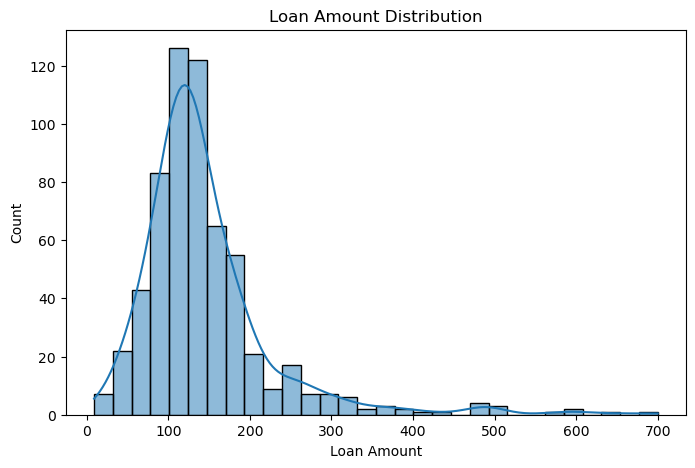

In [13]:
# Distribution of loan amounts
plt.figure(figsize=(8,5))
sns.histplot(df['LoanAmount'], bins=30, kde=True)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Count")
plt.show()

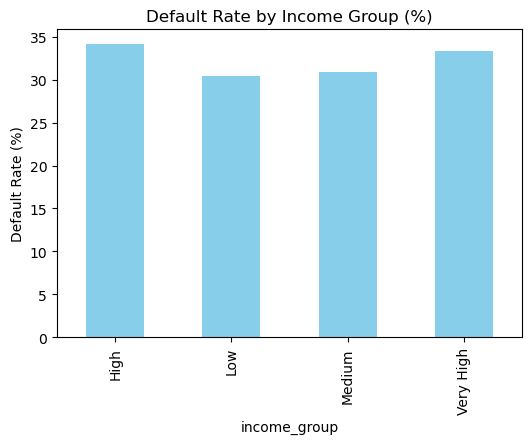

In [14]:
# Default rate by income group
default_by_income = df.groupby('income_group')['default_flag'].mean() * 100
default_by_income.plot(kind='bar', figsize=(6,4), color='skyblue')
plt.title("Default Rate by Income Group (%)")
plt.ylabel("Default Rate (%)")
plt.show()

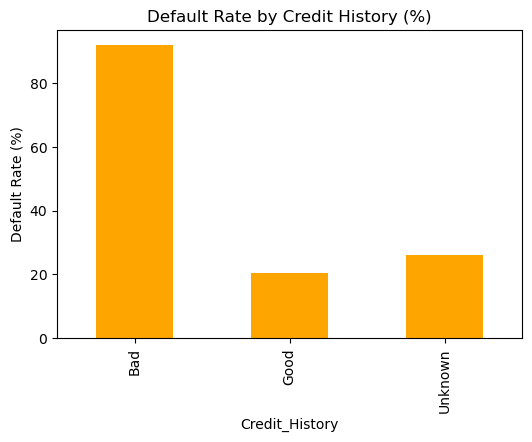

In [15]:
# Default rate by credit history
default_by_credit = df.groupby('Credit_History')['default_flag'].mean() * 100
default_by_credit.plot(kind='bar', figsize=(6,4), color='orange')
plt.title("Default Rate by Credit History (%)")
plt.ylabel("Default Rate (%)")
plt.show()

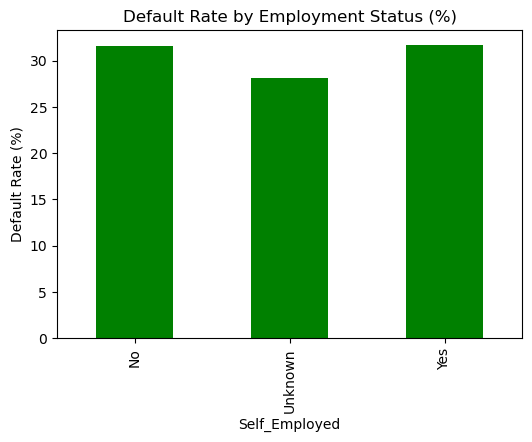

In [16]:
# Default rate by employment status
default_by_emp = df.groupby('Self_Employed')['default_flag'].mean() * 100
default_by_emp.plot(kind='bar', figsize=(6,4), color='green')
plt.title("Default Rate by Employment Status (%)")
plt.ylabel("Default Rate (%)")
plt.show()

## Correlation Analysis

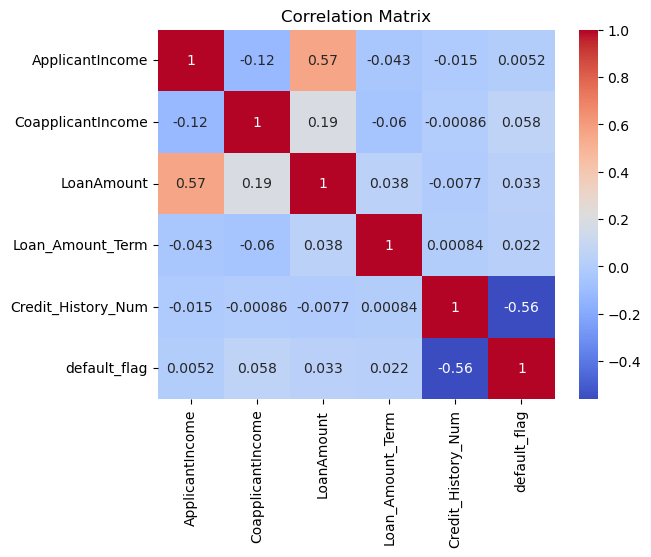

In [17]:
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
# Convert Credit_History back to numeric for correlation if needed
df_corr = df.copy()
df_corr['Credit_History_Num'] = df_corr['Credit_History'].map({'Good':1,'Bad':0,'Unknown':np.nan})

corr = df_corr[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History_Num', 'default_flag']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Logistic Regression Modeling

In [18]:
# Select features (numeric only for simplicity)
X = df_corr[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History_Num']].fillna(0)
y = df_corr['default_flag']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit logistic regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84        88
           1       0.59      0.63      0.61        35

    accuracy                           0.77       123
   macro avg       0.72      0.73      0.73       123
weighted avg       0.78      0.77      0.77       123

ROC AUC: 0.7139610389610389


In [21]:
df.to_csv('../01_data/loan_clean_for_dashboard.csv', index=False)